In [ ]:
import plotly.express as px
import pandas as pd

df = pd.read_csv("../data/global_superstore.csv", encoding="latin1")

fig = px.bar(
    df,
    x="Region",
    y="Sales",
    color="Region"
)

fig.show()

In [ ]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Month Name"] = df["Order Date"].dt.month_name()

region_profit = df.groupby("Region")["Profit"].sum().sort_values()

plt.figure(figsize=(8,5))
region_profit.plot(kind="barh", color="green")

plt.title("Profit by Region")
plt.xlabel("Total Profit")

plt.show()

KeyError: 'Month'

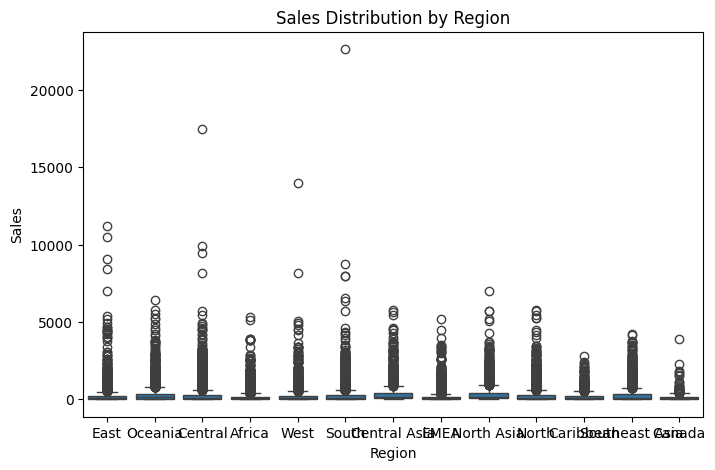

In [41]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Region", y="Sales", data=df)

plt.title("Sales Distribution by Region")

plt.show()

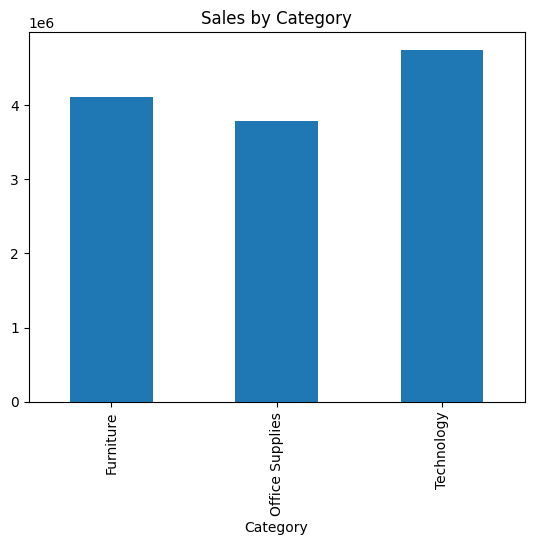

In [42]:
category_sales = df.groupby("Category")["Sales"].sum()

category_sales.plot(kind="bar")

plt.title("Sales by Category")

plt.show()

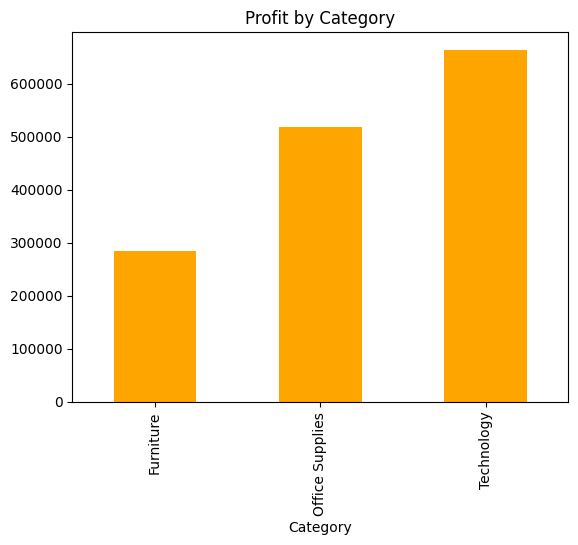

In [43]:
category_profit = df.groupby("Category")["Profit"].sum()

category_profit.plot(kind="bar", color="orange")

plt.title("Profit by Category")

plt.show()

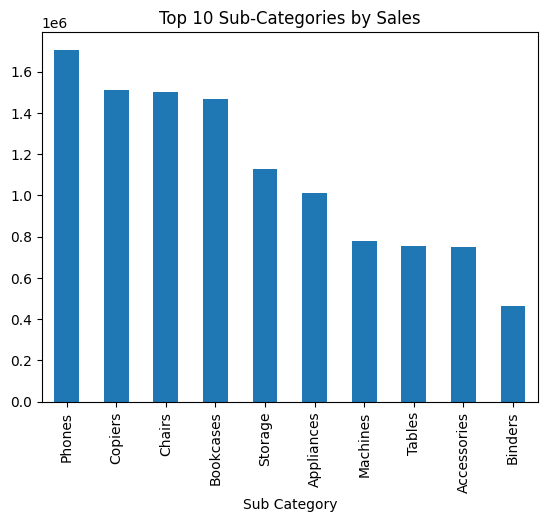

In [45]:
top_subcat = (
    df.groupby("Sub Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_subcat.plot(kind="bar")

plt.title("Top 10 Sub-Categories by Sales")

plt.show()

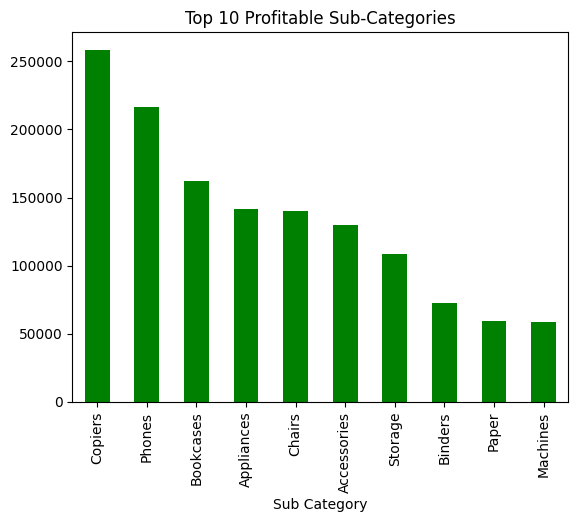

In [46]:
top_profit = (
    df.groupby("Sub Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_profit.plot(kind="bar", color="green")

plt.title("Top 10 Profitable Sub-Categories")

plt.show()

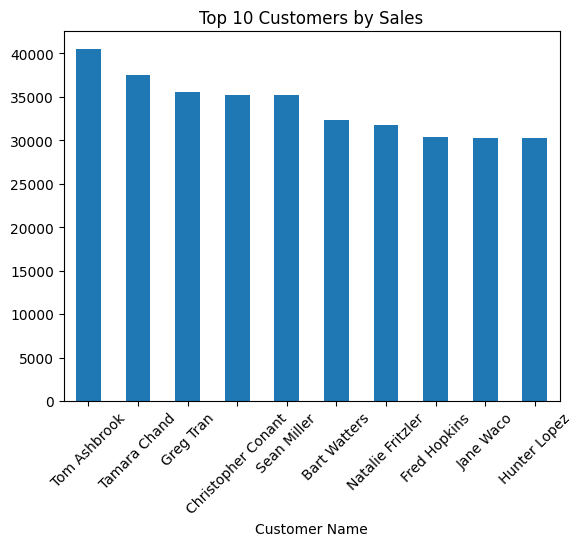

In [47]:
top_customers = (
    df.groupby("Customer Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers.plot(kind="bar")

plt.title("Top 10 Customers by Sales")

plt.xticks(rotation=45)

plt.show()

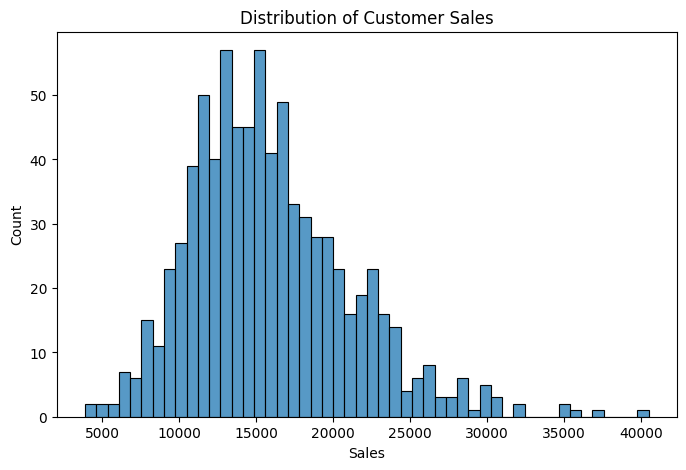

In [48]:
customer_sales = df.groupby("Customer Name")["Sales"].sum()

plt.figure(figsize=(8,5))

sns.histplot(customer_sales, bins=50)

plt.title("Distribution of Customer Sales")

plt.show()

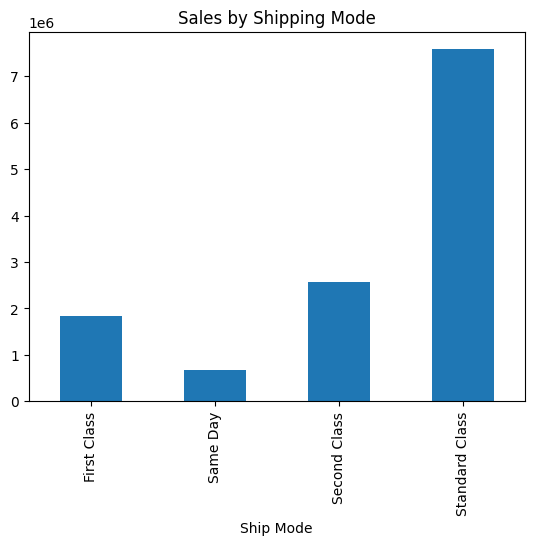

In [49]:
ship_sales = df.groupby("Ship Mode")["Sales"].sum()

ship_sales.plot(kind="bar")

plt.title("Sales by Shipping Mode")

plt.show()

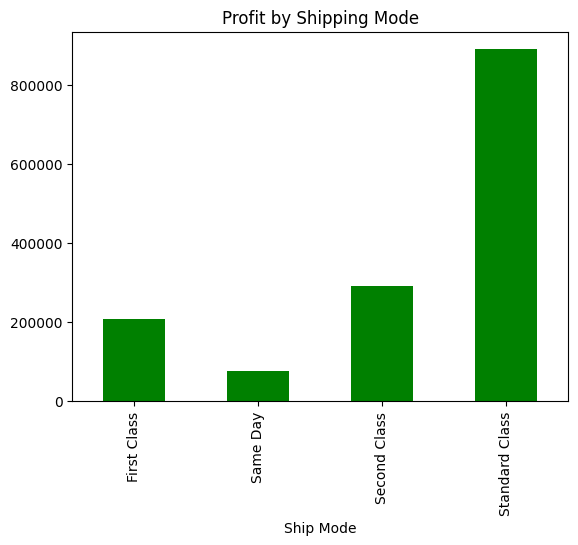

In [50]:
ship_profit = df.groupby("Ship Mode")["Profit"].sum()

ship_profit.plot(kind="bar", color="green")

plt.title("Profit by Shipping Mode")

plt.show()

C:\Users\prava\AppData\Local\Temp\ipykernel_3668\1159912521.py:2: UserWarning:

Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.



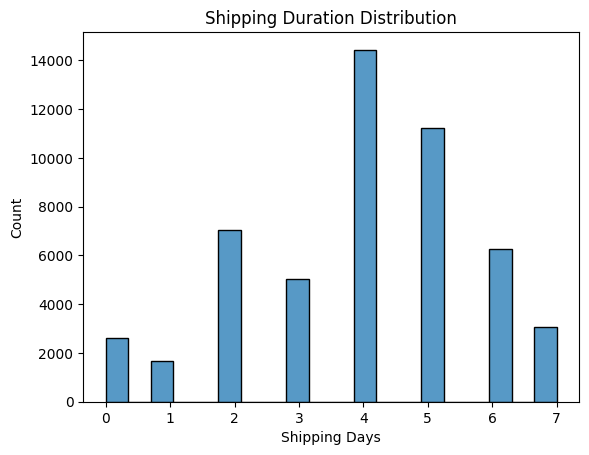

In [51]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

sns.histplot(df["Shipping Days"], bins=20)

plt.title("Shipping Duration Distribution")

plt.show()

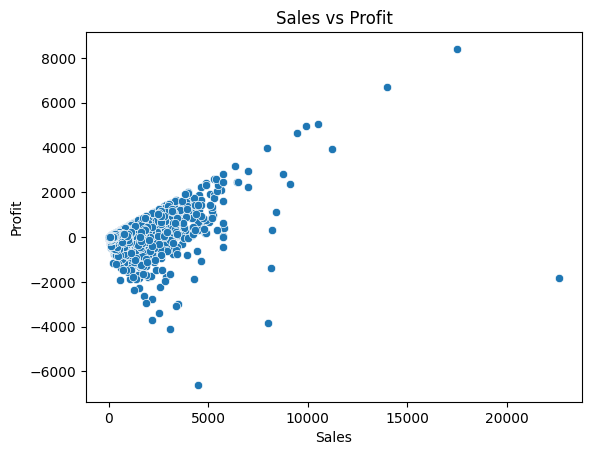

In [52]:
sns.scatterplot(x="Sales", y="Profit", data=df)

plt.title("Sales vs Profit")

plt.show()

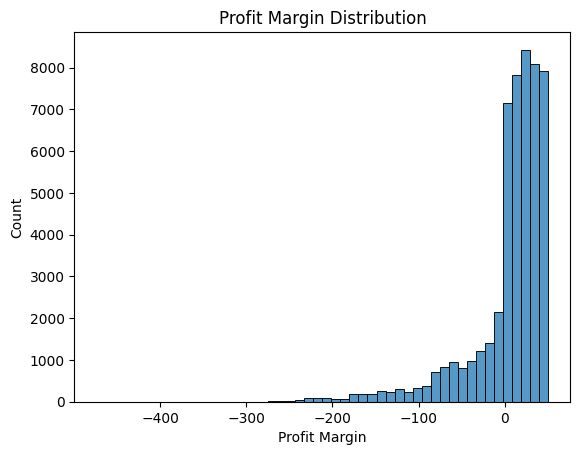

In [53]:
df = preprocess_data(df)

sns.histplot(df["Profit Margin"], bins=50)

plt.title("Profit Margin Distribution")

plt.show()

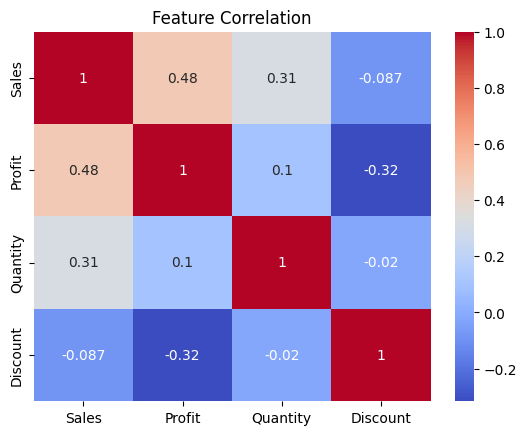

In [54]:
corr = df[["Sales","Profit","Quantity","Discount"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Feature Correlation")

plt.show()

In [55]:
import plotly.express as px

monthly_sales = df.groupby("Month")["Sales"].sum().reset_index()

fig = px.line(
    monthly_sales,
    x="Month",
    y="Sales",
    title="Monthly Sales Trend",
    markers=True
)

fig.show()

In [56]:
country_sales = df.groupby("Country")["Sales"].sum().reset_index()

fig = px.choropleth(
    country_sales,
    locations="Country",
    locationmode="country names",
    color="Sales",
    color_continuous_scale="Blues",
    title="Sales by Country"
)

fig.show()

C:\Users\prava\AppData\Local\Temp\ipykernel_3668\1633414940.py:3: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



In [57]:
fig = px.scatter(
    df,
    x="Discount",
    y="Profit",
    color="Category",
    title="Discount Impact on Profit"
)

fig.show()

In [58]:
category_sales = df.groupby("Category")["Sales"].sum().reset_index()

fig = px.pie(
    category_sales,
    names="Category",
    values="Sales",
    title="Sales Share by Category"
)

fig.show()

In [59]:
subcat_sales = df.groupby(["Category","Sub Category"])["Sales"].sum().reset_index()

fig = px.treemap(
    subcat_sales,
    path=["Category","Sub Category"],
    values="Sales",
    title="Sales Distribution by Category and Subcategory"
)

fig.show()

In [60]:
yearly_sales = df.groupby("Year")["Sales"].sum().reset_index()

fig = px.bar(
    yearly_sales,
    x="Year",
    y="Sales",
    title="Yearly Sales Performance",
    color="Sales",
    color_continuous_scale="Blues"
)

fig.show()

In [61]:
yearly_profit = df.groupby("Year")["Profit"].sum().reset_index()

fig = px.line(
    yearly_profit,
    x="Year",
    y="Profit",
    title="Yearly Profit Trend",
    markers=True
)

fig.show()

In [62]:
import plotly.figure_factory as ff

heatmap_data = df.pivot_table(
    values="Sales",
    index="Region",
    columns="Category",
    aggfunc="sum"
)

fig = ff.create_annotated_heatmap(
    z=heatmap_data.values,
    x=list(heatmap_data.columns),
    y=list(heatmap_data.index),
    colorscale="Blues"
)

fig.update_layout(title="Sales Heatmap: Region vs Category")

fig.show()

In [63]:
top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig = px.bar(
    top_products,
    x="Sales",
    y="Product Name",
    orientation="h",
    title="Top 10 Products by Sales",
    color="Sales"
)

fig.show()

In [64]:
top_profit_products = (
    df.groupby("Product Name")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig = px.bar(
    top_profit_products,
    x="Profit",
    y="Product Name",
    orientation="h",
    title="Top 10 Most Profitable Products",
    color="Profit"
)

fig.show()

In [65]:
fig = px.scatter(
    df,
    x="Discount",
    y="Quantity",
    color="Category",
    title="Discount vs Quantity Purchased"
)

fig.show()

In [66]:
df["Discount Range"] = pd.cut(
    df["Discount"],
    bins=[0,0.1,0.2,0.3,0.4,0.5],
    labels=["0-10%","10-20%","20-30%","30-40%","40-50%"]
)

discount_profit = df.groupby("Discount Range")["Profit"].sum().reset_index()

fig = px.bar(
    discount_profit,
    x="Discount Range",
    y="Profit",
    title="Profit by Discount Range"
)

fig.show()

C:\Users\prava\AppData\Local\Temp\ipykernel_3668\3548071195.py:7: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

